In [8]:
import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
from EDRep_main.EDRep import NodeEmbedding
from functions import *

In [10]:
def block_dists(X_list):
    m = len(X_list)
    blocks = {}
    for i in range(m):
        for j in range(i, m):
            A = X_list[i] @ X_list[j].T
            if i == j:
                # intra-class: upper triangle only (symmetric, diagonal excluded)
                if A.shape[0] > 1:
                    vals = A[np.triu_indices_from(A, k=1)]
                else:
                    continue  # single-node class: no pairs to compare
            else:
                # inter-class: all pairwise products
                vals = A.flatten()
            blocks[(i, j)] = np.sort(vals)
    return blocks

def graph_distance(bd_a, bd_b):
    D = []
    for blk, va in bd_a.items():
        vb = bd_b.get(blk)
        if vb is not None:
            D.append(ot.wasserstein_1d(va, vb, p=2) ** 0.5)
    return np.linalg.norm(D)

Create a graph with sbm and with it do some sanity checks.

In [5]:
class_sizes = [1000, 200, 70]

matrix_1 = np.where(np.eye(3, dtype=bool), 0.8, 0.1)
matrix_2 = np.where(np.eye(3, dtype=bool), 0.6, 0.3)

G_1 = nx.stochastic_block_model(class_sizes, matrix_1 , seed=42)
G_2 = nx.stochastic_block_model(class_sizes, matrix_1 , seed=43)
G_3 = nx.stochastic_block_model(class_sizes, matrix_2 , seed=44)

In [6]:
embedding_dim= 32
def partition(class_sizes):
    part = []
    start = 0
    for i in class_sizes:
        part.append(list(range(start, start + i)))
        start += i
    return part

partitions= partition(class_sizes)
emb_1 = node_embedding(G_1, partitions, embedding_dim)
emb_2 = node_embedding(G_2, partitions, embedding_dim)
emb_3 = node_embedding(G_3, partitions, embedding_dim)


In [11]:
bd_1 = block_dists(emb_1)
bd_2 = block_dists(emb_2)
bd_3 = block_dists(emb_3)

dist_G1_G1 = graph_distance(bd_1, bd_1)
dist_G1_G2 = graph_distance(bd_1, bd_2)
dist_G2_G1 = graph_distance(bd_2, bd_1)
dist_G1_G3 = graph_distance(bd_1, bd_3)
dist_G2_G3 = graph_distance(bd_3, bd_2)

In [12]:
dist_G1_G2+dist_G2_G3>dist_G1_G3

np.True_

In [13]:
dist_G1_G1 = graph_distance(bd_1, bd_1)
dist_G1_G2 = graph_distance(bd_1, bd_2)
dist_G2_G1 = graph_distance(bd_2, bd_1)
dist_G1_G3 = graph_distance(bd_1, bd_3)

print(f"1. Identity d(G_1, G_1): {dist_G1_G1:.4f}")
print(f"2. Symmetry d(G_1, G_2): {dist_G1_G2:.4f} and d(G_2, G_1): {dist_G2_G1:.4f} ")
print(f"3. Distance between similar graphs d(G_1, G_2): {dist_G1_G2:.4f}")
print(f"4. Distance between very different graphs d(G_1, G_3): {dist_G1_G3:.4f}")

1. Identity d(G_1, G_1): 0.0000
2. Symmetry d(G_1, G_2): 0.0105 and d(G_2, G_1): 0.0105 
3. Distance between similar graphs d(G_1, G_2): 0.0105
4. Distance between very different graphs d(G_1, G_3): 1.0356


 We show that mixing the nodes of the same class doesn't change the output while changing them betwwn different class does

In [14]:
def intra_class_perm(partitions):
    perm_partitions = []
    for p in partitions:
        perm_partitions.append(list(np.random.permutation(p)))
    return perm_partitions


perm_partition = intra_class_perm(partitions)
emb_1_perm = node_embedding(G_1, perm_partition, embedding_dim)
dist_G1_G1perm = graph_distance(bd_1, block_dists(emb_1_perm))
print(dist_G1_G1perm)

8.80941133695598e-18


In [15]:
def inter_class_perm(G, partitions):
    class_size = [len(p) for p in partitions]
    shuffled_nodes = list(np.random.permutation(list(G.nodes())))

    new_partitions = []
    for i in partition(class_size):
        new_class = [shuffled_nodes[i] for i in i]
        new_partitions.append(new_class)

    return new_partitions

inter_perm_partition = inter_class_perm(G_1, partitions)
emb_1_inter_perm = node_embedding(G_1, inter_perm_partition, embedding_dim)
dist_G1_G1inter_perm = graph_distance(bd_1, block_dists(emb_1_inter_perm))
print(dist_G1_G1inter_perm)

1.5257007308370663


In [16]:
inter_perm_partition3 = inter_class_perm(G_3, partitions)
emb_3_inter_perm = node_embedding(G_3, inter_perm_partition3, embedding_dim)
dist_G3_G3inter_perm = graph_distance(bd_3, block_dists(emb_3_inter_perm))
print(dist_G3_G3inter_perm)

0.423298124181205


Matched case


In [17]:
def rand_graph_one_in_every_part(n, prob):
   
    G_random = nx.erdos_renyi_graph(n, prob)
    partition_random = [[nodes] for nodes in G_random.nodes()]   
    return G_random, partition_random


In [18]:
G1, part1 = rand_graph_one_in_every_part(500,0.3)
G2, part2 = rand_graph_one_in_every_part(500,0.2)

In [19]:
Embedding1 = node_embedding(G1, part1, 32)
Embedding2 = node_embedding(G2, part2, 32)

dist_G1G2 = graph_distance(block_dists(Embedding1), block_dists(Embedding2))
print(dist_G1G2)

85.54816601011878


In [20]:
x=np.array([e[0] for e in Embedding1])
y=np.array([e[0] for e in Embedding2])
np.linalg.norm(x@x.T-y@y.T)/math.sqrt(2)

np.float64(85.54816601011878)

### Bipartition node migration test

Same graph, bipartition into 2 groups. We start from the true partition (distance = 0) and progressively move nodes from partition 0 to partition 1, tracking how the distance grows.

In [32]:
# 2-block SBM
n_bi = 250
G_bi = nx.stochastic_block_model([n_bi, n_bi],
                                  np.where(np.eye(2, dtype=bool), 0.8, 0.1),
                                  seed=42)

# Compute the global embedding ONCE (graph never changes, only the partition slice does)
np.random.seed(42)
g_bi_sparse = nx.to_scipy_sparse_array(G_bi, format='csr')
emb_obj = NodeEmbedding(g_bi_sparse, dim=embedding_dim, k=1)
X_bi = emb_obj.X  # shape (2*n_bi, embedding_dim)

def slice_partition(X, part0, part1):
    return [X[part0, :], X[part1, :]]

Running the optimization for k = 1


In [33]:
part0_base = list(range(n_bi))           # nodes 0..99   (block 0)
part1_base = list(range(n_bi, 2*n_bi))  # nodes 100..199 (block 1)

emb_base = slice_partition(X_bi, part0_base, part1_base)
bd_base = block_dists(emb_base)
dist_self = graph_distance(bd_base, bd_base)
print(f"Distance to self (bipartition): {dist_self:.6f}")

# Move nodes[0], nodes[1], ... from part0 into part1 one at a time.
# Stop before part0 becomes empty (empty partition breaks block_dists).
distances_migration = []

for k in range(n_bi):
    moved     = part0_base[:k]      # first k nodes of block 0, now in block 1
    new_part0 = part0_base[k:]      # remaining nodes in block 0
    new_part1 = part1_base + moved

    if len(new_part0) == 0:
        break

    emb_k = slice_partition(X_bi, new_part0, new_part1)
    bd_k  = block_dists(emb_k)
    dist_k = graph_distance(bd_base, bd_k)
    distances_migration.append(dist_k)

Distance to self (bipartition): 0.000000


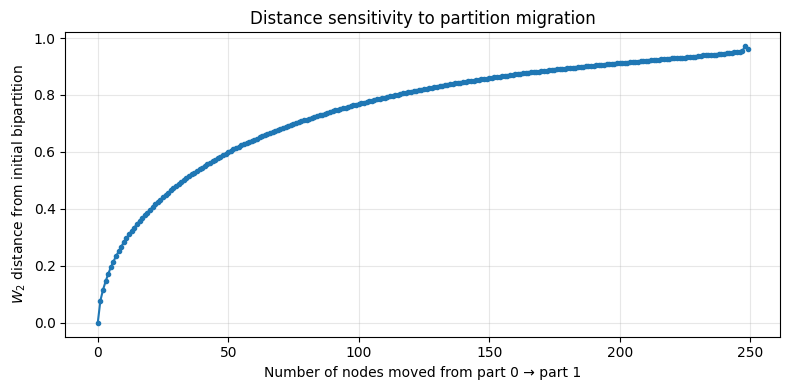

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(distances_migration)), distances_migration, marker='o', markersize=3, linewidth=1.5)
plt.xlabel("Number of nodes moved from part 0 → part 1")
plt.ylabel("$W_2$ distance from initial bipartition")
plt.title("Distance sensitivity to partition migration")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()